# Generate water price and availability timeseries

- Water availability should be given as a variation, so each data point represents the variation with respect to the previous one.
- We should start with an initial value, and then based on the precipitation add, and substract some amount due to evaporation.
- The evaporation rate probably should be a linear function of the weather conditions (HR, Tamb): $\dot{V}_{loss} = a \cdot HR + b \cdot T_{amb} + c, \in [\underline{\dot{V}_{loss}}, \overline{\dot{V}_{loss}}]$
- To simplify the problem, assume a constat loss rate
- The relationship precipitation and water availability is arbitrary. To start with something, model it so that during winter the wet cooling tower could operate exclusively by using this water source, while on summer it would not suffice.


[Data source](https://collab.psa.es/apps/files/files/1267204?dir=/E47/E47_TECHNICAL/DESAL%20PROJECTS/1K235_SOLHYCOOL/Ejecuci%C3%B3n/T2.2%20-%20Optimizaci%C3%B3n%20de%20la%20operaci%C3%B3n&openfile=true)

In [1]:
from typing import Literal
from pathlib import Path
from loguru import logger
import datetime
import numpy as np
import pandas as pd
from datetime import time

from solhycool_evaluation.utils import repeat_and_align_index

%load_ext autoreload
%autoreload 2

# Paths
data_path: Path = Path("../../data/datasets/partial")
output_path: Path = Path("../results/visualizations")
data_output_path: Path = data_path
# Parameters
environment_id: Literal["psa", "med_eds", "andasol", "psa_andasol"] = "andasol_pilot_plant"  # Options: psa, med_eds, andasol


# Alternative A. Model water availability as a function of precipitation data
# Vavail_max: float = 1.2 # m³/day
# Vavail_min: float = 0.0 # m³/day
# availability_start_time = time(0, 0)  # e.g., water becomes available from 08:00 onward

# Alternative B. Asign some initial value and some rando variation factor
# Vavail0: float = 20. # Period initial volume, m³
# evap_rate: float = -0.0 # Evaporation rate, m³/h

"""
If a filename for the electricity data is provided, the cost of the alternative
source is calculated based on the electricity price data. Otherwise the cost is
calculated based on the water price.
"""

params_dict: dict = {
    "psa": {
        "year_start": 2022,
        "year_end": 2024,
        "weather_data_fn": "tmy_2005_tabernas.h5",
        "electricity_data_fn": "electricity_price_data_20211231_20241231.h5",
        "Vavail_max": 1.2, # m³/day
        "Vavail_min": 0.0, # m³/day
        "water_price": 0.0290538951, # €/m³, Morocco
        "alternative_source_cost_multiplier":  8 * 10, # €/m³, multiplier /100 (l/h) * 1000 (l/m³)
    },
    "med_eds": {
        "year_start": 2022,
        "year_end": 2024,
        "weather_data_fn": "tmy_2005_Borg_El_Arab.h5",
        "electricity_data_fn": "electricity_price_data_20211231_20241231.h5",
        "Vavail_max": 1.2, # m³/day
        "Vavail_min": 0.0, # m³/day,
        "availability_start_time": time(8, 0),
        "water_price": 0.06047057835, # €/m³, Egypt
        "alternative_source_cost_multiplier":  8 * 10, # multiplier x /100 l/h * 1000 l/m³
    },
    "andasol": {
        "weather_data_fn": "tmy_2005_guadix.h5",
        "electricity_data_fn": "electricity_price_data_20211231_20241231.h5",
        "year_start": 2022,
        "year_end": 2024,
        "Vavail_max": 1.2, # m³/day
        "Vavail_min": 0.0, # m³/day,
        "water_price": 0.0290538951, # €/m³, Morocco
        "alternative_source_cost_multiplier":  8 * 10, # multiplier x /100 l/h * 1000 l/m³
    },
    "andasol_pilot_plant": {
        "weather_data_fn": "tmy_2005_guadix.h5",
        "electricity_data_fn": "electricity_price_data_20211231_20241231.h5",
        "year_start": 2022,
        "year_end": 2023,
        "Vavail_max": 2.0, # m³/day
        "Vavail_min": 0.0, # m³/day,
        "water_price": 0.0290538951, # €/m³, Morocco
        "alternative_source_cost_multiplier":  8 * 10, # multiplier x /100 l/h * 1000 l/m³
    }
}

assert environment_id in params_dict.keys(), f"environment_id should be available in params_dict, options are: {list(params_dict.keys())}"
params = params_dict[environment_id]

weather_data_path: Path = data_path / params["weather_data_fn"]
year_start: int = params["year_start"]
year_end: int = params["year_end"]

if "electricity_data_fn" in params:
    electricity_price_data_path: Path = data_path / params["electricity_data_fn"]
    alternative_source_cost = pd.read_hdf(electricity_price_data_path)["Ce_spot_market_price_eur_kWh"] * params["alternative_source_cost_multiplier"]
else:
    alternative_source_cost = params["water_price"] * params["alternative_source_cost_multiplier"]

water_price = params["water_price"]
Vavail_max = params["Vavail_max"]  # m³/day
Vavail_min = params["Vavail_min"]  # m³/day
availability_start_time = params.get("availability_start_time", time(0, 0))  # e.g., water becomes available from 08:00 onward


## Prices

In [2]:
# Create a pandas series with one-hour resolution
start_date = datetime.datetime(year_start, 1, 1, 0, 0, 0)
end_date = datetime.datetime(year_end, 12, 31, 23, 0, 0)
date_rng = pd.date_range(start=start_date, end=end_date, freq='h', tz='UTC')
fname: str = f"water_data_{environment_id}_{start_date:%Y%m%d}_{end_date:%Y%m%d}"

# Initialize dataframe
df = pd.DataFrame(
    data={
        "water_price_eur_m3": water_price,
        "water_price_alternative_eur_m3": alternative_source_cost,
    },
    index=date_rng,
)
# Add columns for the water price in liters
for col in df.columns:
    df[col.replace("_eur_m3", "_eur_l")] = df[col] / 1000.0

df


,water_price_eur_m3,water_price_alternative_eur_m3,water_price_eur_l,water_price_alternative_eur_l
2022-01-01 00:00:00+00:00,0.029054,9.1920,0.000029,0.009192
2022-01-01 01:00:00+00:00,0.029054,9.1096,0.000029,0.009110
2022-01-01 02:00:00+00:00,0.029054,7.8240,0.000029,0.007824
2022-01-01 03:00:00+00:00,0.029054,7.8240,0.000029,0.007824
2022-01-01 04:00:00+00:00,0.029054,7.6592,0.000029,0.007659
...,...,...,...,...
2023-12-31 19:00:00+00:00,0.029054,7.4376,0.000029,0.007438
2023-12-31 20:00:00+00:00,0.029054,6.8392,0.000029,0.006839
2023-12-31 21:00:00+00:00,0.029054,5.9792,0.000029,0.005979
2023-12-31 22:00:00+00:00,0.029054,5.7568,0.000029,0.005757


In [9]:
alternative_source_cost.std()


np.float64(5.585947836741767)

## Model water availability as a function of precipitation data

<Axes: xlabel='time'>

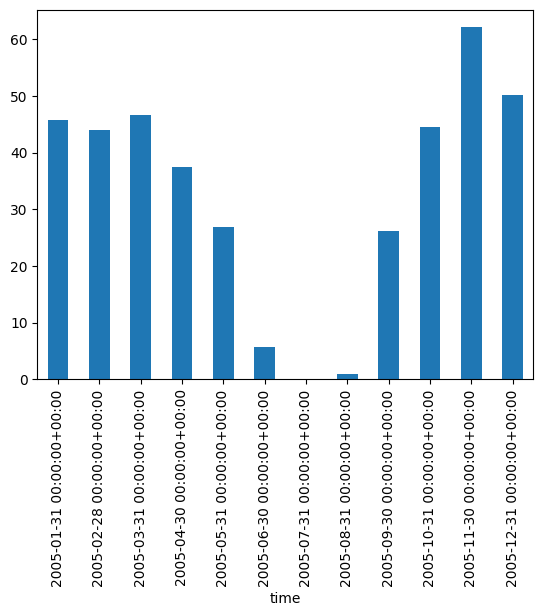

In [3]:
# Read weather data and resample precipitation data to monthly acumulating the precipitation per month
precip_data = pd.read_hdf(weather_data_path)["precip_mm"].resample("ME").sum()
display(precip_data.plot(kind="bar"))


In [4]:
conversion_factor = Vavail_max / precip_data.max()  # m³/mm

# Convert daily precipitation to daily volume
Vavail_daily = (precip_data * conversion_factor).rename("Vavail_m3")

# Resample to hourly with repeat (forward-fill)
Vavail_hourly = repeat_and_align_index(
    Vavail_daily.resample("h").ffill(), new_index=df.index, year_range=(year_start, year_end)
)

# Build a proper Series mask aligned with Vavail_hourly index
mask_available = pd.Series(Vavail_hourly.index.time >= availability_start_time, index=Vavail_hourly.index)

# Apply mask
Vavail_hourly_masked = Vavail_hourly.where(mask_available, 0)

# Assign to DataFrame
df["Vavail_m3"] = Vavail_hourly_masked
df["Vavail_l"] = df["Vavail_m3"] * 1e3


In [5]:
# # For now just assign some initial value at the start of the timeseries,
# # and then increase/decrease it by the same amount every day

# # deltaV: hourly volume variation (m³/h)
# # Vavail: available water volume (m³)

# # Terribly inefficient, but whatever it's only done once
# current_month = start_date.month
# for single_date in pd.date_range(start=start_date, end=end_date, freq='h', tz='UTC'):
#     if single_date.month != current_month:
#         current_month = single_date.month
#         Vavail = Vavail0 # Reset available volume every month
#     deltaV = evap_rate + np.random.uniform(0.8*evap_rate, 1.2*evap_rate)
#     Vavail = Vavail0 + deltaV
#     df.loc[single_date, "Vavail_m3"] = Vavail
#     df.loc[single_date, "deltaV_m3_h"] = deltaV
#     df.loc[single_date, "Vavail_l"] = Vavail*1e3
#     df.loc[single_date, "deltaV_l_h"] = deltaV*1e3

# df


In [6]:
# Export dataframe including additional units (liters)
df.to_hdf(data_output_path / f"{fname}.h5", key="data", mode="w", format="table")
df.to_csv(data_output_path / f"{fname}.csv")

logger.info(f"Exported data to {data_output_path / fname}")


2025-09-19 20:24:56.705 | INFO     | __main__:<module>:5 - Exported data to ../../data/datasets/partial/water_data_andasol_pilot_plant_20220101_20231231


In [7]:
df = pd.read_hdf(data_output_path / f"{fname}.h5", index_col=0, parse_dates=True)
df


,water_price_eur_m3,water_price_alternative_eur_m3,water_price_eur_l,water_price_alternative_eur_l,Vavail_m3,Vavail_l
2022-01-01 00:00:00+00:00,0.029054,9.1920,0.000029,0.009192,1.475040,1475.040258
2022-01-01 01:00:00+00:00,0.029054,9.1096,0.000029,0.009110,1.475040,1475.040258
2022-01-01 02:00:00+00:00,0.029054,7.8240,0.000029,0.007824,1.475040,1475.040258
2022-01-01 03:00:00+00:00,0.029054,7.8240,0.000029,0.007824,1.475040,1475.040258
2022-01-01 04:00:00+00:00,0.029054,7.6592,0.000029,0.007659,1.475040,1475.040258
...,...,...,...,...,...,...
2023-12-31 19:00:00+00:00,0.029054,7.4376,0.000029,0.007438,1.613527,1613.526570
2023-12-31 20:00:00+00:00,0.029054,6.8392,0.000029,0.006839,1.613527,1613.526570
2023-12-31 21:00:00+00:00,0.029054,5.9792,0.000029,0.005979,1.613527,1613.526570
2023-12-31 22:00:00+00:00,0.029054,5.7568,0.000029,0.005757,1.613527,1613.526570


In [8]:
# Visualize data

from plotly_resampler import FigureWidgetResampler
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

var_ids: list[str] = [
    ["water_price_eur_m3", "water_price_alternative_eur_m3",], 
    "Vavail_m3",
]
var_units: list[str] = ["€/m<sup>3</sup>","m<sup>3</sup>"]

fig = make_subplots(rows=len(var_ids), cols=1, shared_xaxes=True)
fig = FigureWidgetResampler(fig)

for i, (var_id, var_unit) in enumerate(zip(var_ids, var_units)):
    var_id = [var_id] if not isinstance(var_id, list) else var_id
    
    for v_id in var_id:
        fig.add_trace(
            go.Scattergl(name=v_id.replace("_", " "), showlegend=True), 
            hf_x=df.index, 
            hf_y=np.ascontiguousarray( df[v_id] ), 
            # max_n_samples=2_000,
            row=i + 1, col=1
        )
    fig.update_yaxes(title_text=var_unit, row=i + 1)
    
# Temporal
data_L = pd.read_csv(data_path / "water_data_andasol_escalada_20050101_20051231.csv", index_col=0, parse_dates=True)
data_L = repeat_and_align_index(data_L, new_index=df.index, year_range=(year_start, year_end))
fig.add_trace(
    go.Scattergl(name="data L", showlegend=True), 
    hf_x=data_L.index, 
    hf_y=np.ascontiguousarray( data_L[v_id] ), 
    # max_n_samples=2_000,
    row=2, col=1
)

fig.update_layout(
    height=1000,
    width=800,
    title="<b>Environment variables</b>",
    title_x=0.1,
    legend_traceorder="normal",
    legend=dict(orientation="h", y=1.15, xanchor="left", x=0),
    margin=dict(l=20, r=20, t=250, b=20),
)

fig


ImportError: Please install anywidget to use the FigureWidget class

In [ ]:
from phd_visualizations import save_figure

if fig.layout.xaxis.range is not None:
    start, end = fig.layout.xaxis.range
else:
    start, end = df.index[0].strftime("%Y-%m-%d %H:%M:%S.%f")[:-2], df.index[-1].strftime("%Y-%m-%d %H:%M:%S.%f")[:-2]

save_figure(fig, f"solhycool_water_viz_{environment_id}_{start[:10].replace('-', '')}_{end[:10].replace('-', '')}", 
            figure_path=output_path, formats=["png", "svg"])


2025-04-15 09:31:10.618 | INFO     | phd_visualizations:save_figure:38 - Figure saved in [PosixPath('../results/visualizations')]/solhycool_water_viz_psa_20220101_20241231.png
2025-04-15 09:31:14.221 | INFO     | phd_visualizations:save_figure:38 - Figure saved in [PosixPath('../results/visualizations')]/solhycool_water_viz_psa_20220101_20241231.svg
